In [1]:
# Install if needed (uncomment if running fresh)
# !pip install nltk scikit-learn pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import warnings
warnings.filterwarnings('ignore')

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

# Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

print('All libraries imported successfully!')

All libraries imported successfully!


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\nsai6\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\nsai6\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\nsai6\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# Load dataset
df = pd.read_csv('IMDB Dataset.csv')

print('Shape:', df.shape)
print('\nFirst 3 rows:')
df.head(3)

Shape: (50000, 2)

First 3 rows:


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive


Sentiment distribution:
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


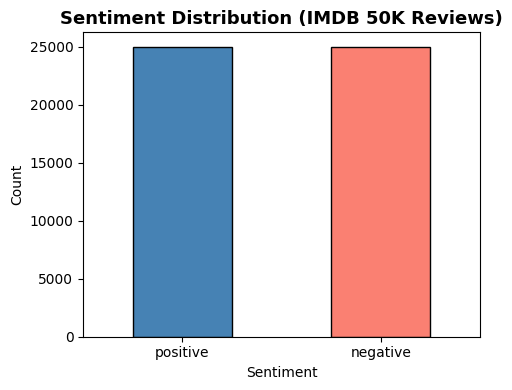

Dataset is perfectly balanced — 25,000 positive + 25,000 negative


In [3]:
# Check class balance
print('Sentiment distribution:')
print(df['sentiment'].value_counts())

# Visualize
plt.figure(figsize=(5, 4))
df['sentiment'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Sentiment Distribution (IMDB 50K Reviews)', fontsize=13, fontweight='bold')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print('Dataset is perfectly balanced — 25,000 positive + 25,000 negative')

In [4]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """Full NLP preprocessing pipeline."""
    
    # 1. Remove HTML tags (IMDB reviews often have <br /> tags)
    text = re.sub(r'<.*?>', ' ', text)
    
    # 2. Keep only alphabets
    text = re.sub(r'[^a-zA-Z]', ' ', text)
    
    # 3. Lowercase
    text = text.lower()
    
    # 4. Tokenization — split sentence into words
    tokens = word_tokenize(text)
    
    # 5. Stop word removal — remove 'the', 'is', 'a', etc.
    tokens = [t for t in tokens if t not in stop_words]
    
    # 6. Stemming — reduce 'loved' → 'love', 'movies' → 'movi'
    tokens = [stemmer.stem(t) for t in tokens]
    
    return ' '.join(tokens)

# Demo on one review
sample = df['review'][0]
print('ORIGINAL REVIEW (first 200 chars):')
print(sample[:200])
print('\nAFTER PREPROCESSING:')
print(preprocess_text(sample)[:200])

ORIGINAL REVIEW (first 200 chars):
One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me abo

AFTER PREPROCESSING:
one review mention watch oz episod hook right exactli happen first thing struck oz brutal unflinch scene violenc set right word go trust show faint heart timid show pull punch regard drug sex violenc 


In [5]:
# Apply preprocessing to all 50,000 reviews
# This takes 2-4 minutes — normal!
print('⏳ Preprocessing 50,000 reviews... please wait...')
df['clean_review'] = df['review'].apply(preprocess_text)
print('Preprocessing complete!')
df[['review', 'clean_review', 'sentiment']].head(3)

⏳ Preprocessing 50,000 reviews... please wait...
Preprocessing complete!


,review,clean_review,sentiment
0,One of the other reviewers has mentioned that ...,one review mention watch oz episod hook right ...,positive
1,A wonderful little production. <br /><br />The...,wonder littl product film techniqu unassum old...,positive
2,I thought this was a wonderful way to spend ti...,thought wonder way spend time hot summer weeke...,positive


In [6]:
# Encode labels: positive=1, negative=0
df['label'] = df['sentiment'].map({'positive': 1, 'negative': 0})

X = df['clean_review']
y = df['label']

# 80% train, 20% test — standard split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training samples : {len(X_train):,}')
print(f'Testing samples  : {len(X_test):,}')
print('Split done — 80/20 with stratification')

Training samples : 40,000
Testing samples  : 10,000
Split done — 80/20 with stratification


In [8]:
# TF-IDF: top 50,000 features, unigrams + bigrams
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),    # captures 'not good' and 'very bad' together
    sublinear_tf=True      # dampens very high term frequencies
)

# Fit on train only (never fit on test — data leakage!)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f'TF-IDF matrix shape (train): {X_train_tfidf.shape}')
print(f'TF-IDF matrix shape (test) : {X_test_tfidf.shape}')
print('Text converted to TF-IDF feature matrix')

TF-IDF matrix shape (train): (40000, 50000)
TF-IDF matrix shape (test) : (10000, 50000)
Text converted to TF-IDF feature matrix


In [9]:
# Train Logistic Regression
print('Training Logistic Regression...')
lr_model = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', random_state=42)
lr_model.fit(X_train_tfidf, y_train)

# Predict
lr_pred = lr_model.predict(X_test_tfidf)
lr_acc  = accuracy_score(y_test, lr_pred)

print(f'\n Logistic Regression Accuracy: {lr_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, lr_pred, target_names=['Negative', 'Positive']))

Training Logistic Regression...

 Logistic Regression Accuracy: 90.21%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.89      0.90      5000
    Positive       0.89      0.91      0.90      5000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000



In [10]:
# Train Naive Bayes
print('Training Naive Bayes...')
nb_model = MultinomialNB(alpha=0.1)
nb_model.fit(X_train_tfidf, y_train)

# Predict
nb_pred = nb_model.predict(X_test_tfidf)
nb_acc  = accuracy_score(y_test, nb_pred)

print(f'\n Naive Bayes Accuracy: {nb_acc * 100:.2f}%')
print('\nClassification Report:')
print(classification_report(y_test, nb_pred, target_names=['Negative', 'Positive']))

Training Naive Bayes...

 Naive Bayes Accuracy: 87.94%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.87      0.88      5000
    Positive       0.87      0.89      0.88      5000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



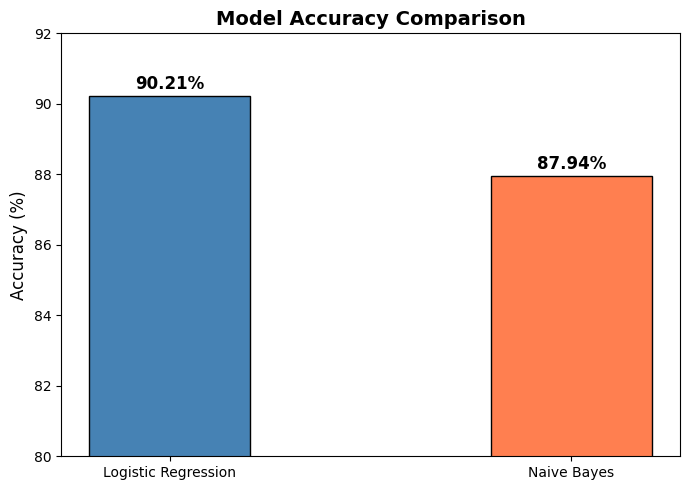

In [11]:
models = ['Logistic Regression', 'Naive Bayes']
accs   = [lr_acc * 100, nb_acc * 100]

plt.figure(figsize=(7, 5))
bars = plt.bar(models, accs, color=['steelblue', 'coral'], width=0.4, edgecolor='black')
plt.ylim([80, 92])
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Model Accuracy Comparison', fontsize=14, fontweight='bold')
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{acc:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

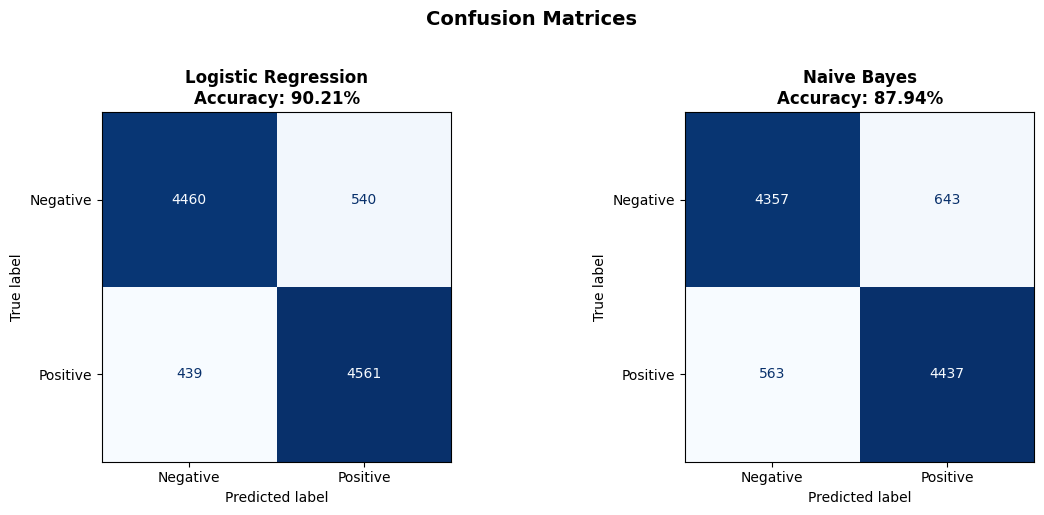

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, pred, title in zip(
    axes,
    [lr_pred, nb_pred],
    ['Logistic Regression', 'Naive Bayes']
):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                   display_labels=['Negative', 'Positive'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{title}\nAccuracy: {accuracy_score(y_test, pred)*100:.2f}%',
                 fontsize=12, fontweight='bold')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

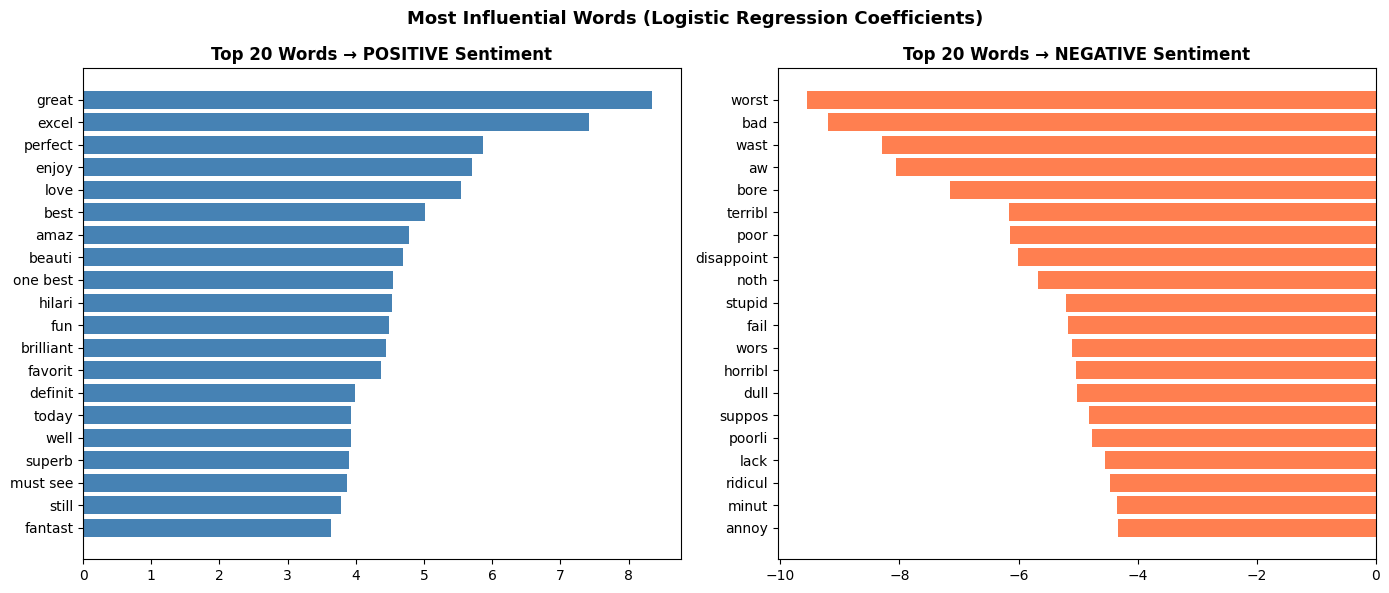

In [13]:
feature_names = np.array(tfidf.get_feature_names_out())
coefs = lr_model.coef_[0]

top_pos_idx = np.argsort(coefs)[-20:][::-1]
top_neg_idx = np.argsort(coefs)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Top positive words
axes[0].barh(feature_names[top_pos_idx], coefs[top_pos_idx], color='steelblue')
axes[0].set_title('Top 20 Words → POSITIVE Sentiment', fontweight='bold')
axes[0].invert_yaxis()

# Top negative words
axes[1].barh(feature_names[top_neg_idx], coefs[top_neg_idx], color='coral')
axes[1].set_title('Top 20 Words → NEGATIVE Sentiment', fontweight='bold')
axes[1].invert_yaxis()

plt.suptitle('Most Influential Words (Logistic Regression Coefficients)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

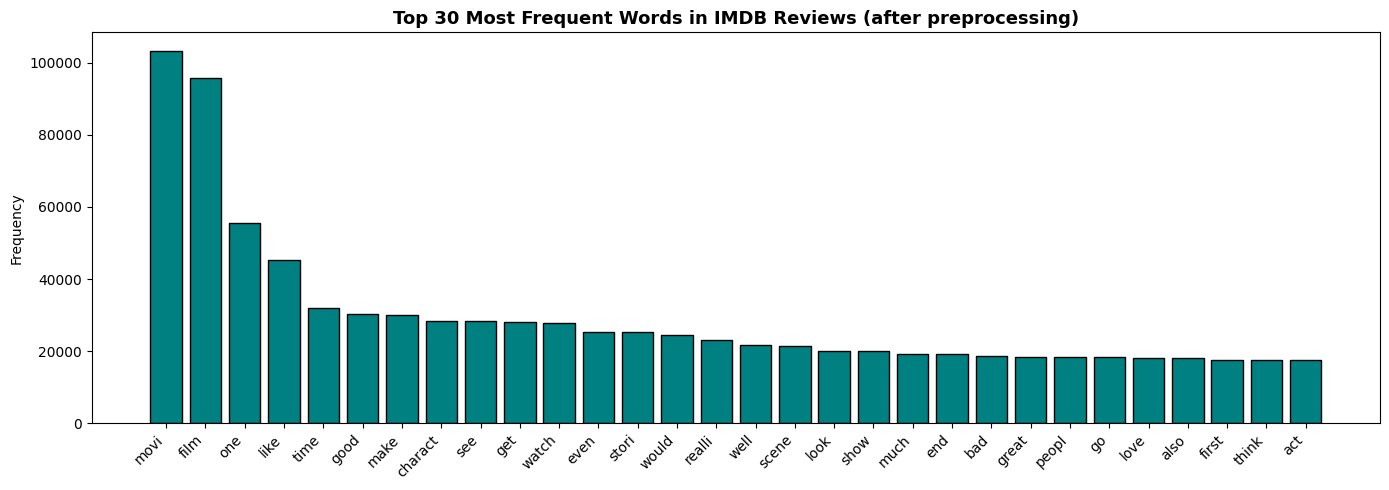

In [14]:
from collections import Counter

all_words = ' '.join(df['clean_review']).split()
word_freq  = Counter(all_words).most_common(30)
words, freqs = zip(*word_freq)

plt.figure(figsize=(14, 5))
plt.bar(words, freqs, color='teal', edgecolor='black')
plt.xticks(rotation=45, ha='right')
plt.title('Top 30 Most Frequent Words in IMDB Reviews (after preprocessing)',
          fontsize=13, fontweight='bold')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [15]:
print('=' * 50)
print('   FINAL RESULTS SUMMARY')
print('=' * 50)
print(f'  Logistic Regression : {lr_acc * 100:.2f}% accuracy')
print(f'  Naive Bayes         : {nb_acc * 100:.2f}% accuracy')
print('=' * 50)
best = 'Logistic Regression' if lr_acc >= nb_acc else 'Naive Bayes'
best_acc = max(lr_acc, nb_acc) * 100
print(f'  Best Model: {best} ({best_acc:.2f}%)')
print('=' * 50)

   FINAL RESULTS SUMMARY
  Logistic Regression : 90.21% accuracy
  Naive Bayes         : 87.94% accuracy
  Best Model: Logistic Regression (90.21%)


In [17]:
def predict_sentiment(review_text, model=lr_model):
    """Predict sentiment of any custom movie review."""
    cleaned   = preprocess_text(review_text)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    label = 'POSITIVE' if prediction == 1 else 'NEGATIVE'
    confidence = probability[prediction] * 100
    print(f'Review   : {review_text[:80]}...')
    print(f'Sentiment: {label}')
    print(f'Confidence: {confidence:.1f}%')

# ---- Try your own reviews below ----
predict_sentiment("This movie was absolutely brilliant! One of the best films I have ever seen.")
print()
predict_sentiment("Terrible movie. Complete waste of time. The acting was awful and boring.")

Review   : This movie was absolutely brilliant! One of the best films I have ever seen....
Sentiment: POSITIVE
Confidence: 98.0%

Review   : Terrible movie. Complete waste of time. The acting was awful and boring....
Sentiment: NEGATIVE
Confidence: 100.0%
